In [1]:
%pip install ultraplot xskillscore -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import datacube
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import ultraplot as uplt
import xskillscore
from matplotlib.dates import MonthLocator
from datacube.drivers.netcdf import write_dataset_to_netcdf
from scipy.stats import pearsonr

import sys
sys.path.insert(1, '.../Tools')
from dea_tools.datahandling import load_ard
from dea_tools.plotting import rgb, display_map
from dea_tools.dask import create_local_dask_cluster
from dea_tools.bandindices import calculate_indices

In [3]:
create_local_dask_cluster()

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/8787/status,
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/8787/status,Workers: 1
Total threads: 7,Total memory: 59.21 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:37031,Workers: 1
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/8787/status,Total threads: 7
Started: Just now,Total memory: 59.21 GiB
Comm: tcp://127.0.0.1:41997,Total threads: 7
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/41039/status,Memory: 59.21 GiB
Nanny: tcp://127.0.0.1:42819,


In [4]:
dc = datacube.Datacube(app="TCP_initial_exploration")

In [5]:
# calculate statistics over the individual TC scenes
def reduce(ds):
    yy = xr_quantile_bands(ds, [0.1, 0.5, 0.9], nodata=np.nan)
    return yy

In [6]:
lat = -35.5200
lon = 144.0000
buffer = 0.05


lat_range = (lat - buffer, lat + buffer)
lon_range = (lon - buffer, lon + buffer)

resolution = (-30, 30)
measurements = ["nbart_blue", "nbart_green", "nbart_red", "nbart_nir", "nbart_swir_1", "nbart_swir_2", "oa_fmask", "oa_nbart_contiguity"]
dask_chunks = dict(time=10, x=512, y=512)

In [7]:
#display_map(x=lon_range, y=lat_range)

In [8]:
# set up baseline dc query. THis will be modified by functions as needed later on.
query = {
    'x': lon_range,
    'y': lat_range,
    'time': ('2024-01', '2024-12'),
    'measurements': measurements,
    'resolution': resolution,
    'group_by': 'solar_day',
    'output_crs': 'EPSG:3577'
}

In [9]:
ds = load_ard(
    dc=dc,
    products=['ga_ls8c_ard_3', 'ga_ls9c_ard_3'],
    cloud_mask = 'fmask',
    mask_pixel_quality=True,
    mask_contiguity = True,
    **query
)

Finding datasets
    ga_ls8c_ard_3
    ga_ls9c_ard_3
Applying fmask pixel quality/cloud mask
Applying contiguity mask (oa_nbart_contiguity)
Loading 91 time steps


/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


In [10]:
print(f"time range: {pd.to_datetime(ds.time.min().values).strftime('%Y-%b-%d')} to {pd.to_datetime(ds.time.max().values).strftime('%Y-%b-%d')}")
#ds

time range: 2024-Jan-01 to 2024-Dec-26


<xarray.Dataset> Size: 316MB
Dimensions:              (time: 91, y: 398, x: 336)
Coordinates:
  * time                 (time) datetime64[ns] 728B 2024-01-01T00:09:22.12330...
  * y                    (y) float64 3kB -3.925e+06 -3.925e+06 ... -3.937e+06
  * x                    (x) float64 3kB 1.08e+06 1.08e+06 ... 1.09e+06 1.09e+06
    spatial_ref          int32 4B 3577
Data variables:
    nbart_blue           (time, y, x) float32 49MB 821.0 804.0 ... 258.0 245.0
    nbart_green          (time, y, x) float32 49MB 1.115e+03 1.084e+03 ... 412.0
    nbart_red            (time, y, x) float32 49MB 1.329e+03 1.214e+03 ... 436.0
    nbart_nir            (time, y, x) float32 49MB 2.535e+03 2.544e+03 ... 525.0
    nbart_swir_1         (time, y, x) float32 49MB 3.164e+03 3.119e+03 ... 283.0
    nbart_swir_2         (time, y, x) float32 49MB 2.509e+03 2.399e+03 ... 132.0
    oa_fmask             (time, y, x) uint8 12MB 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 5
    oa_nbart_contiguity  (time, y, x) uint8 12MB 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [11]:
ds_tc = calculate_indices(ds, 
                          index=['TCW', 'TCB', 'TCG', 'TCW_ls8ls9', 'TCB_ls8ls9', 'TCG_ls8ls9'], 
                          drop=True,
                          inplace=True,
                          collection = 'ga_ls_3')

Dropping bands ['nbart_blue', 'nbart_green', 'nbart_red', 'nbart_nir', 'nbart_swir_1', 'nbart_swir_2', 'oa_fmask', 'oa_nbart_contiguity']


In [12]:
# find difference between the two versions of the TC
ds_tc['TCW_diff'] = ds_tc['TCW'] - ds_tc['TCW_ls8ls9']
ds_tc['TCG_diff'] = ds_tc['TCG'] - ds_tc['TCG_ls8ls9']
ds_tc['TCB_diff'] = ds_tc['TCB'] - ds_tc['TCB_ls8ls9']

In [13]:
ds_tc_sub = ds_tc
#ds_tc_sub = ds_tc.isel(time=slice(None, None, 5),x=slice(None, None, 5), y=slice(None, None, 5)) #sub-sampling to speed up graph generation
#ds_tc_sub

<xarray.Dataset> Size: 438MB
Dimensions:      (time: 91, y: 398, x: 336)
Coordinates:
  * time         (time) datetime64[ns] 728B 2024-01-01T00:09:22.123303 ... 20...
  * y            (y) float64 3kB -3.925e+06 -3.925e+06 ... -3.937e+06 -3.937e+06
  * x            (x) float64 3kB 1.08e+06 1.08e+06 ... 1.09e+06 1.09e+06
    spatial_ref  int32 4B 3577
Data variables:
    TCW          (time, y, x) float32 49MB -0.2619 -0.2562 ... 0.007866 0.003667
    TCB          (time, y, x) float32 49MB 0.3231 0.3168 ... 0.09733 0.08216
    TCG          (time, y, x) float32 49MB 0.05477 0.0639 ... 0.01898 0.002717
    TCW_ls8ls9   (time, y, x) float32 49MB -0.1752 -0.1713 ... 0.02662 0.01787
    TCB_ls8ls9   (time, y, x) float32 49MB 0.4685 0.4578 ... 0.1007 0.08578
    TCG_ls8ls9   (time, y, x) float32 49MB 0.04334 0.05293 ... 0.01178 -0.002771
    TCW_diff     (time, y, x) float32 49MB -0.0867 -0.0849 ... -0.01876 -0.01421
    TCG_diff     (time, y, x) float32 49MB 0.01143 0.01097 ... 0.007197 0.005488
    TCB_diff     (time, y, x) float32 49MB -0.1453 -0.141 ... -0.003615
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [14]:
%%time
ds_diff = np.stack([ds_tc_sub['TCW_diff'].values.flatten(), ds_tc_sub['TCG_diff'].values.flatten(), ds_tc_sub['TCB_diff'].values.flatten()], axis=1)
ds_diff.shape

CPU times: user 76.2 ms, sys: 53.4 ms, total: 130 ms
Wall time: 125 ms


(12169248, 3)

CPU times: user 670 ms, sys: 66.2 ms, total: 736 ms
Wall time: 716 ms


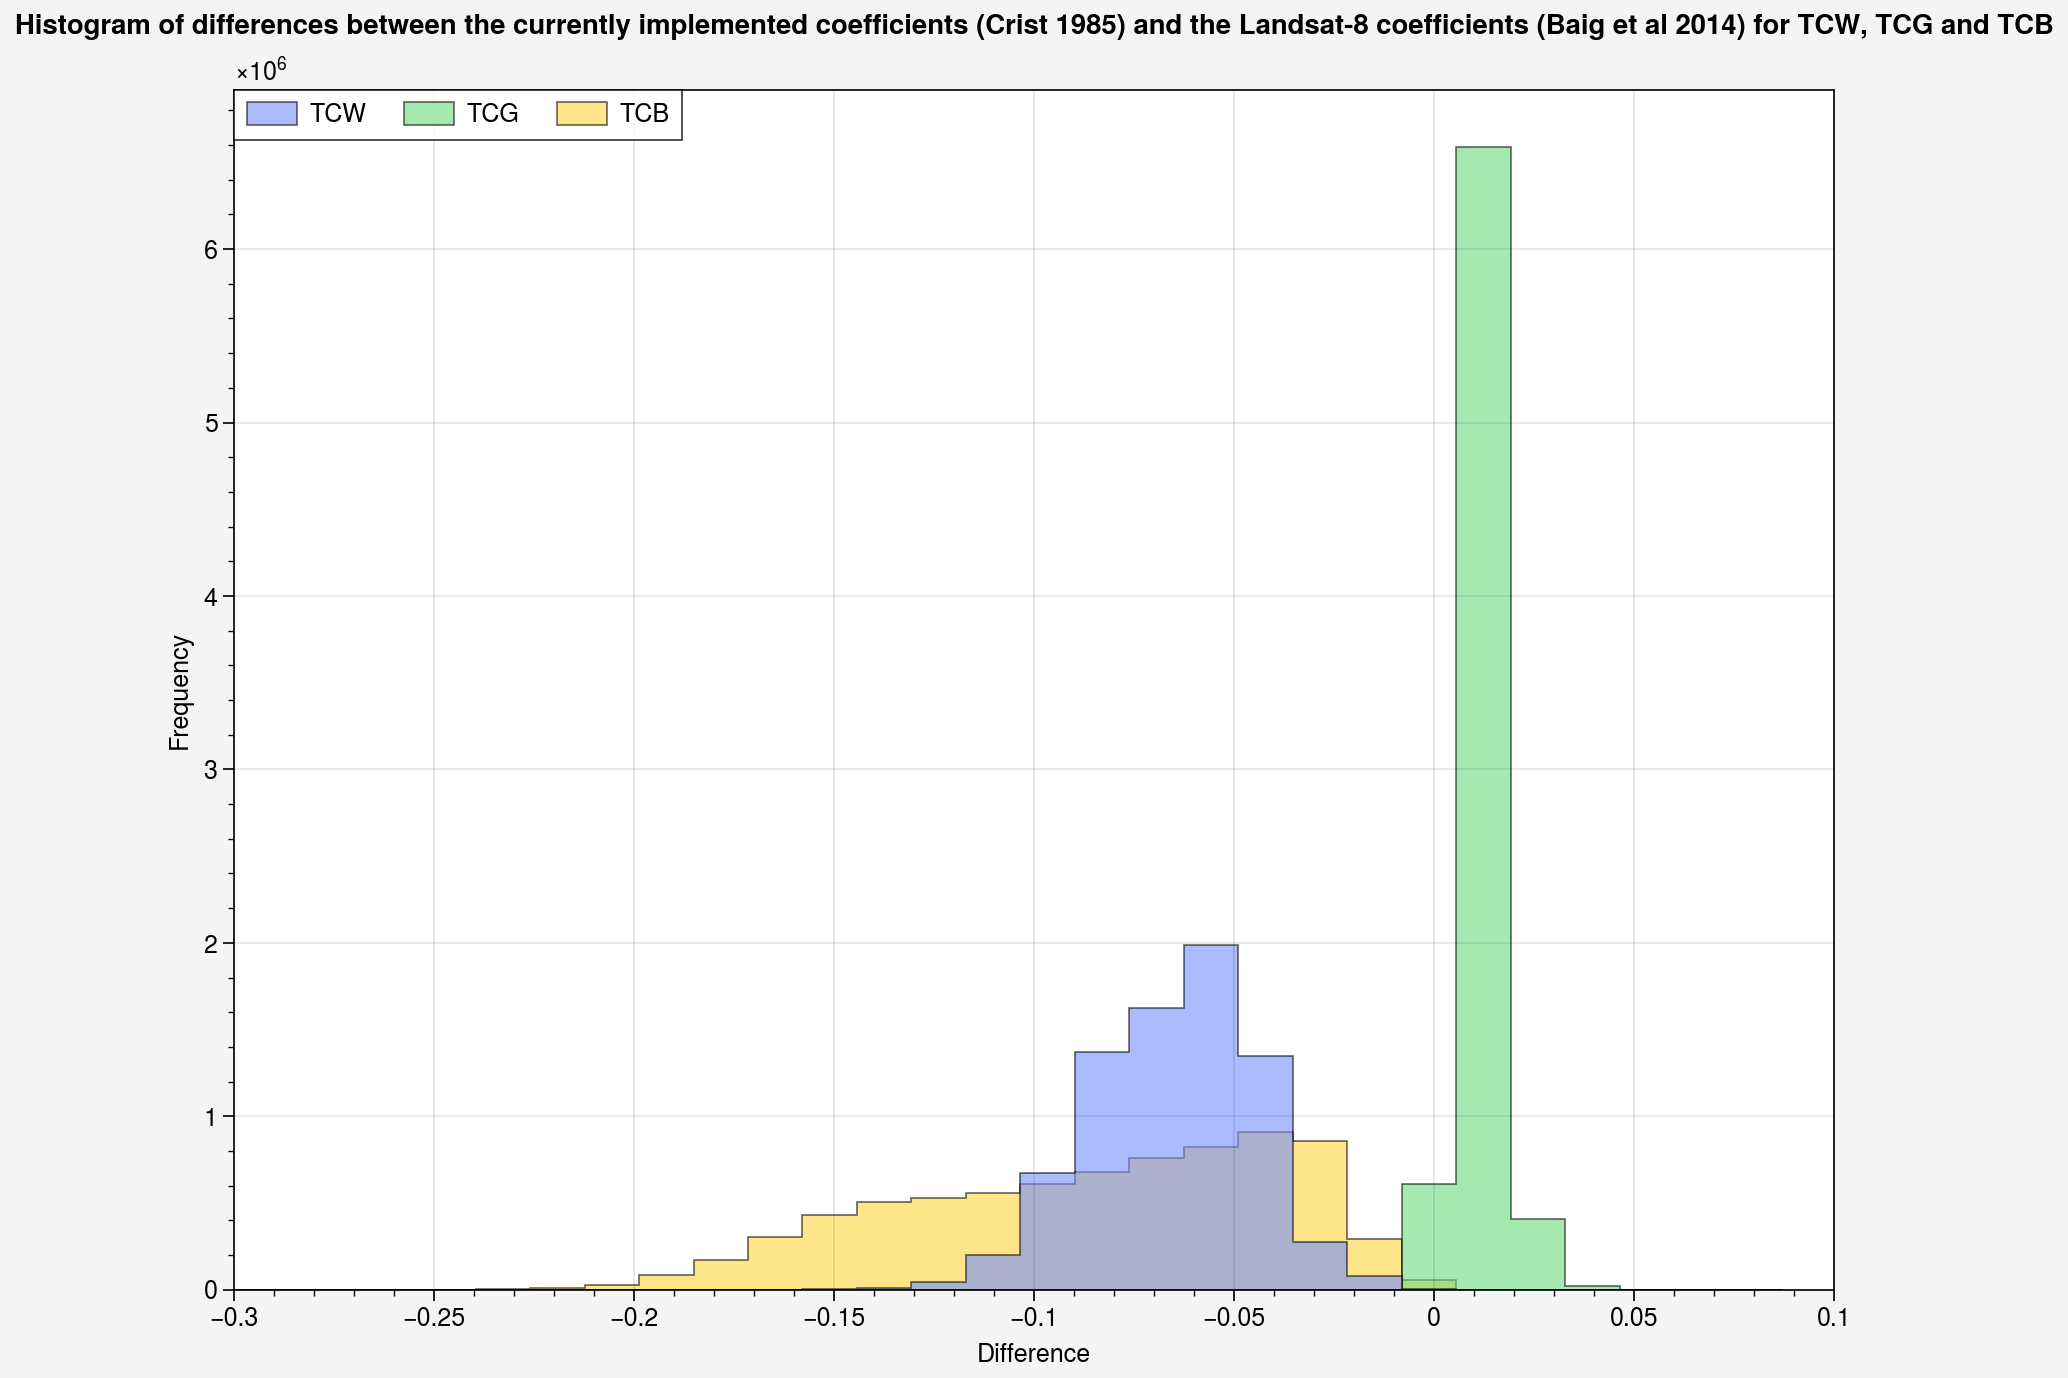

In [15]:
%%time
# plot histogram subplots for the 3 TC's

fig, ax = uplt.subplots(refwidth=6, refaspect=(3,1.5))
ax.format(suptitle='Histogram of differences between the currently implemented coefficients (Crist 1985) and the Landsat-8 coefficients (Baig et al 2014) for TCW, TCG and TCB', xlabel='Difference', ylabel='Frequency')
res = ax.hist(
    ds_diff,
    bins=50,
    histtype='stepfilled',
    filled=True,
    alpha=0.6,
    edgecolor='k',
    cycle=('indigo4', 'green4', 'yellow4'),
    labels=list(['TCW', 'TCG', 'TCB']),
    legend='ul'
    
)
ax.format(xlim=(-0.3, 0.1))

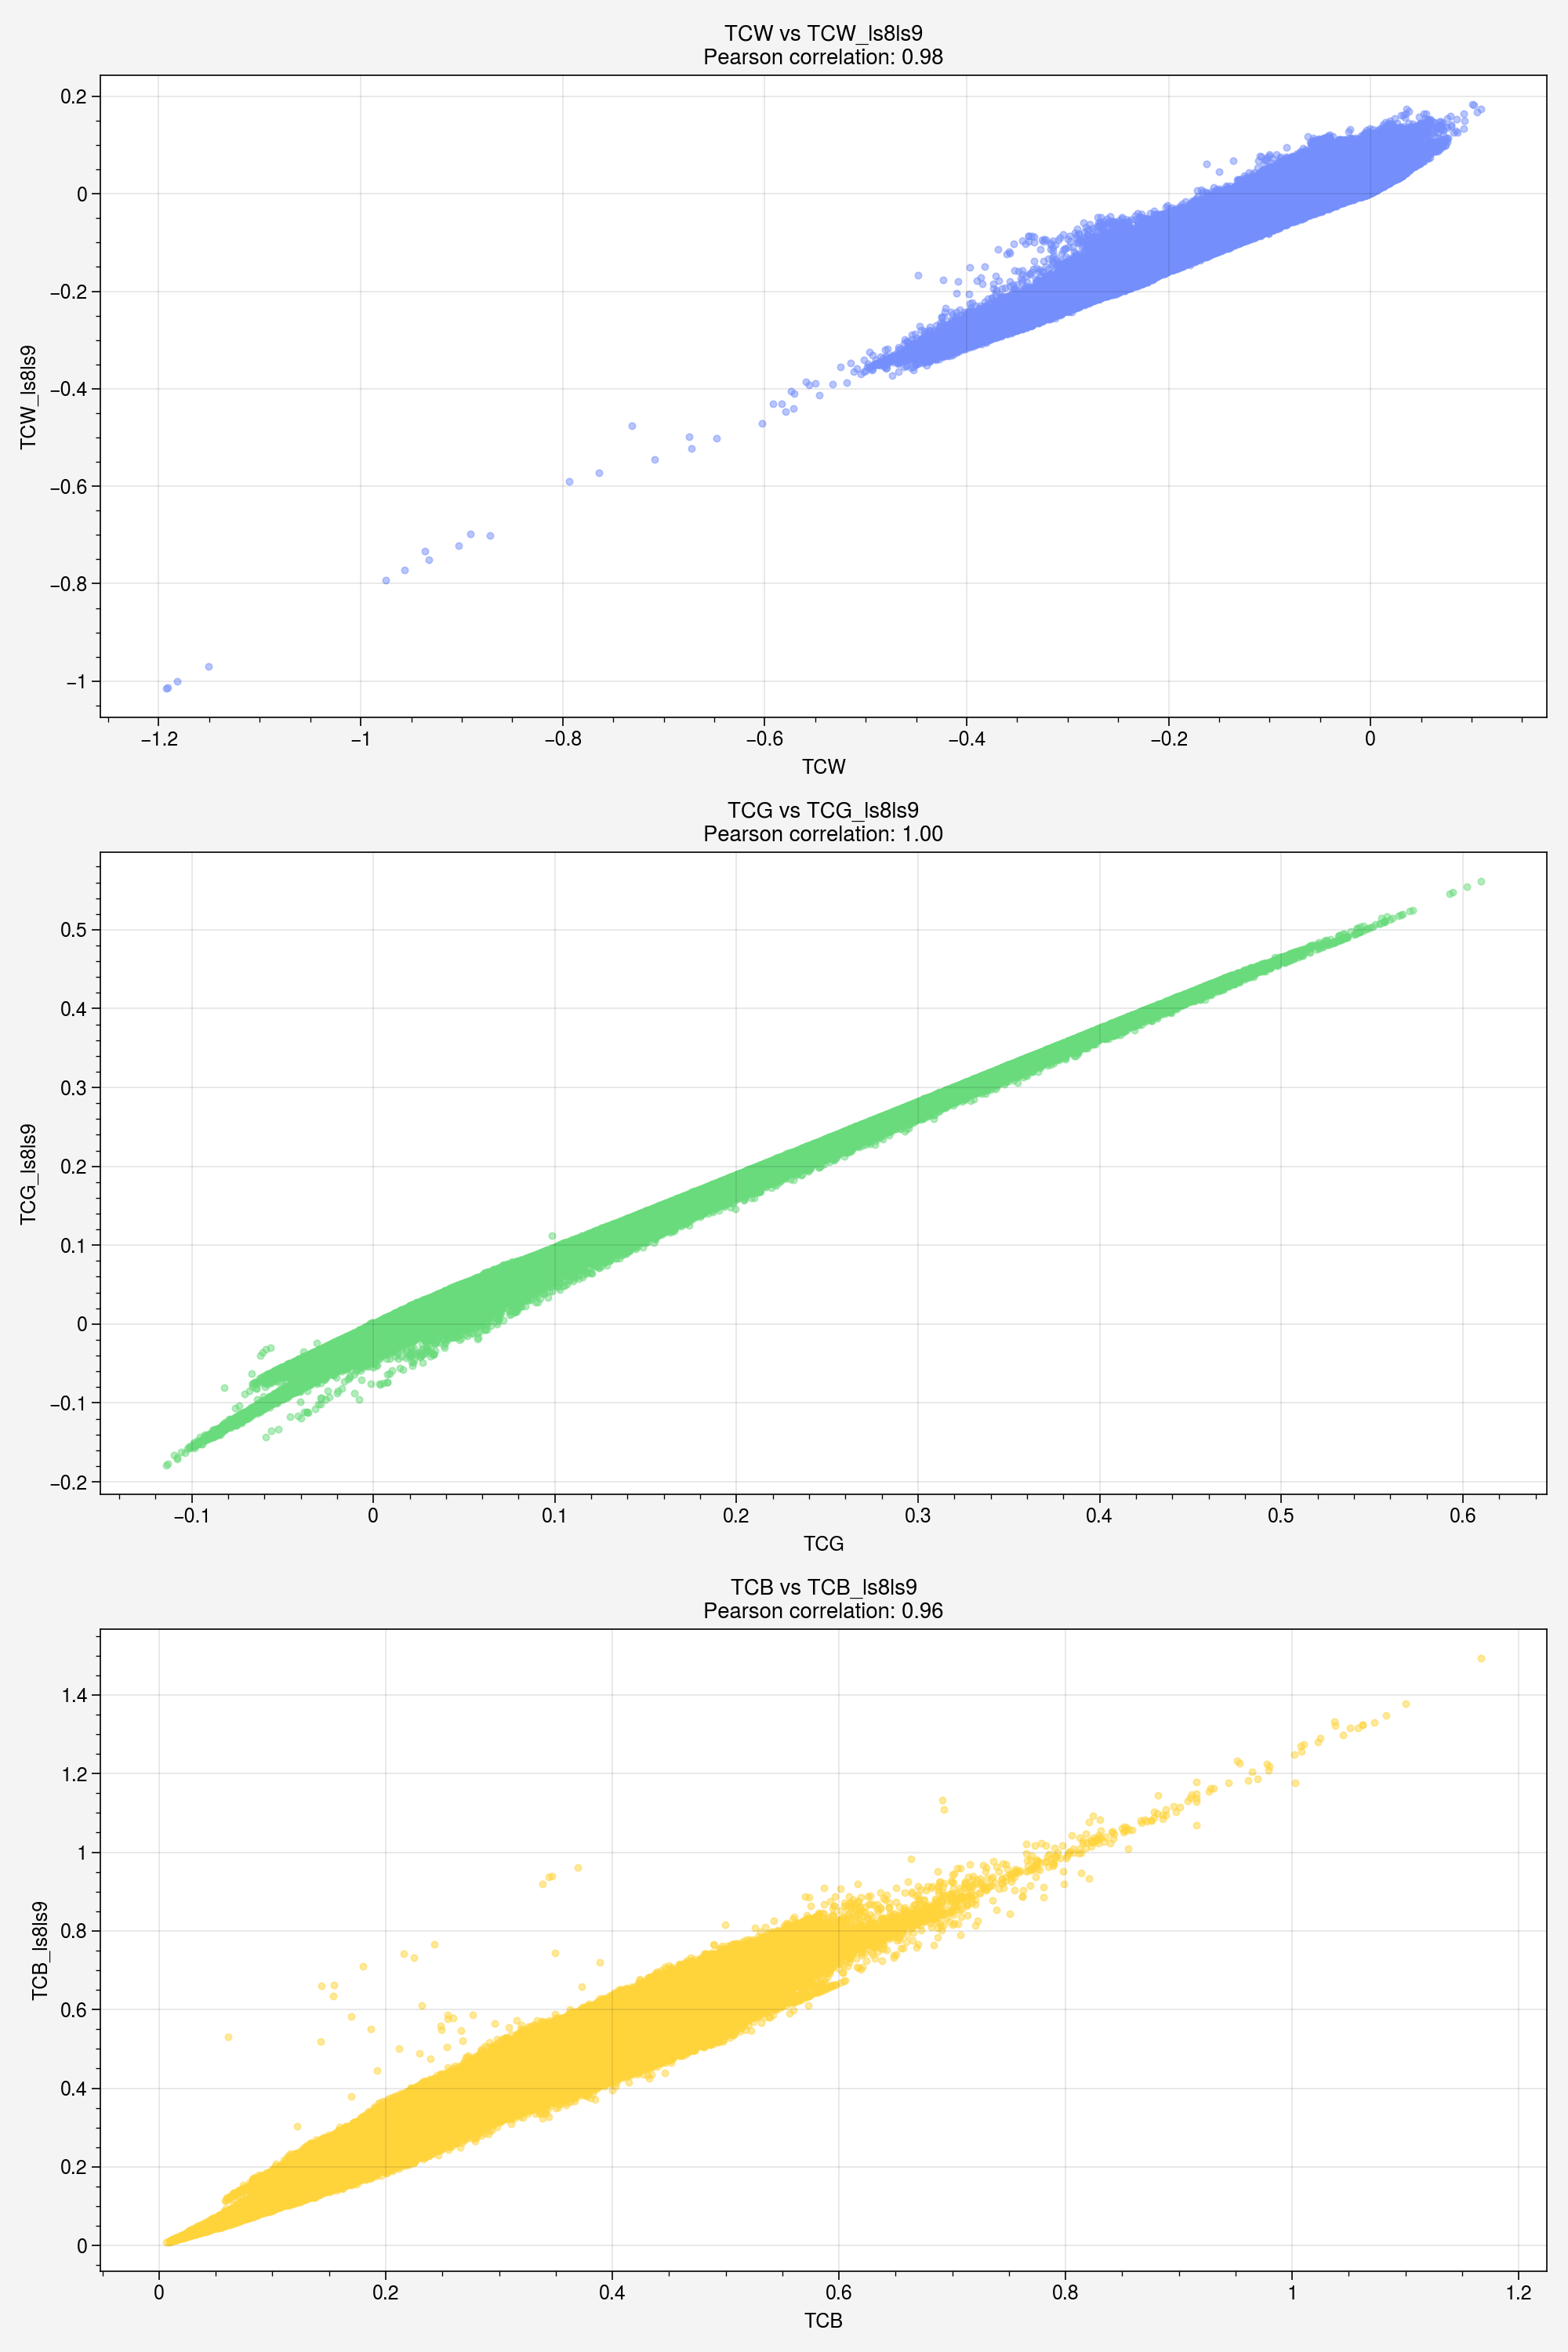

In [16]:
variable_pairs = [
    ('TCW', 'TCW_ls8ls9'),
    ('TCG', 'TCG_ls8ls9'),
    ('TCB', 'TCB_ls8ls9')
]

colors = ('indigo4', 'green4', 'yellow4')

fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(6,9))

for i, ((var1, var2), color) in enumerate(zip(variable_pairs, colors)):
    ax=axs[i]

    data1 = ds_tc_sub[var1].values.ravel()
    data2 = ds_tc_sub[var2].values.ravel()

    # remove nans for correlation and plotting
    mask = ~np.isnan(data1) & ~np.isnan(data2)
    data1_clean = data1[mask]
    data2_clean = data2[mask]

    ax.scatter(data1_clean, data2_clean, alpha=0.5, marker='.', c=color)
    corr, _ = pearsonr(data1_clean, data2_clean)

    # annotate
    ax.set_title(f'{var1} vs {var2}\nPearson correlation: {corr:.2f}')
    ax.set_xlabel(var1)
    ax.set_ylabel(var2)

plt.tight_layout()
plt.show()

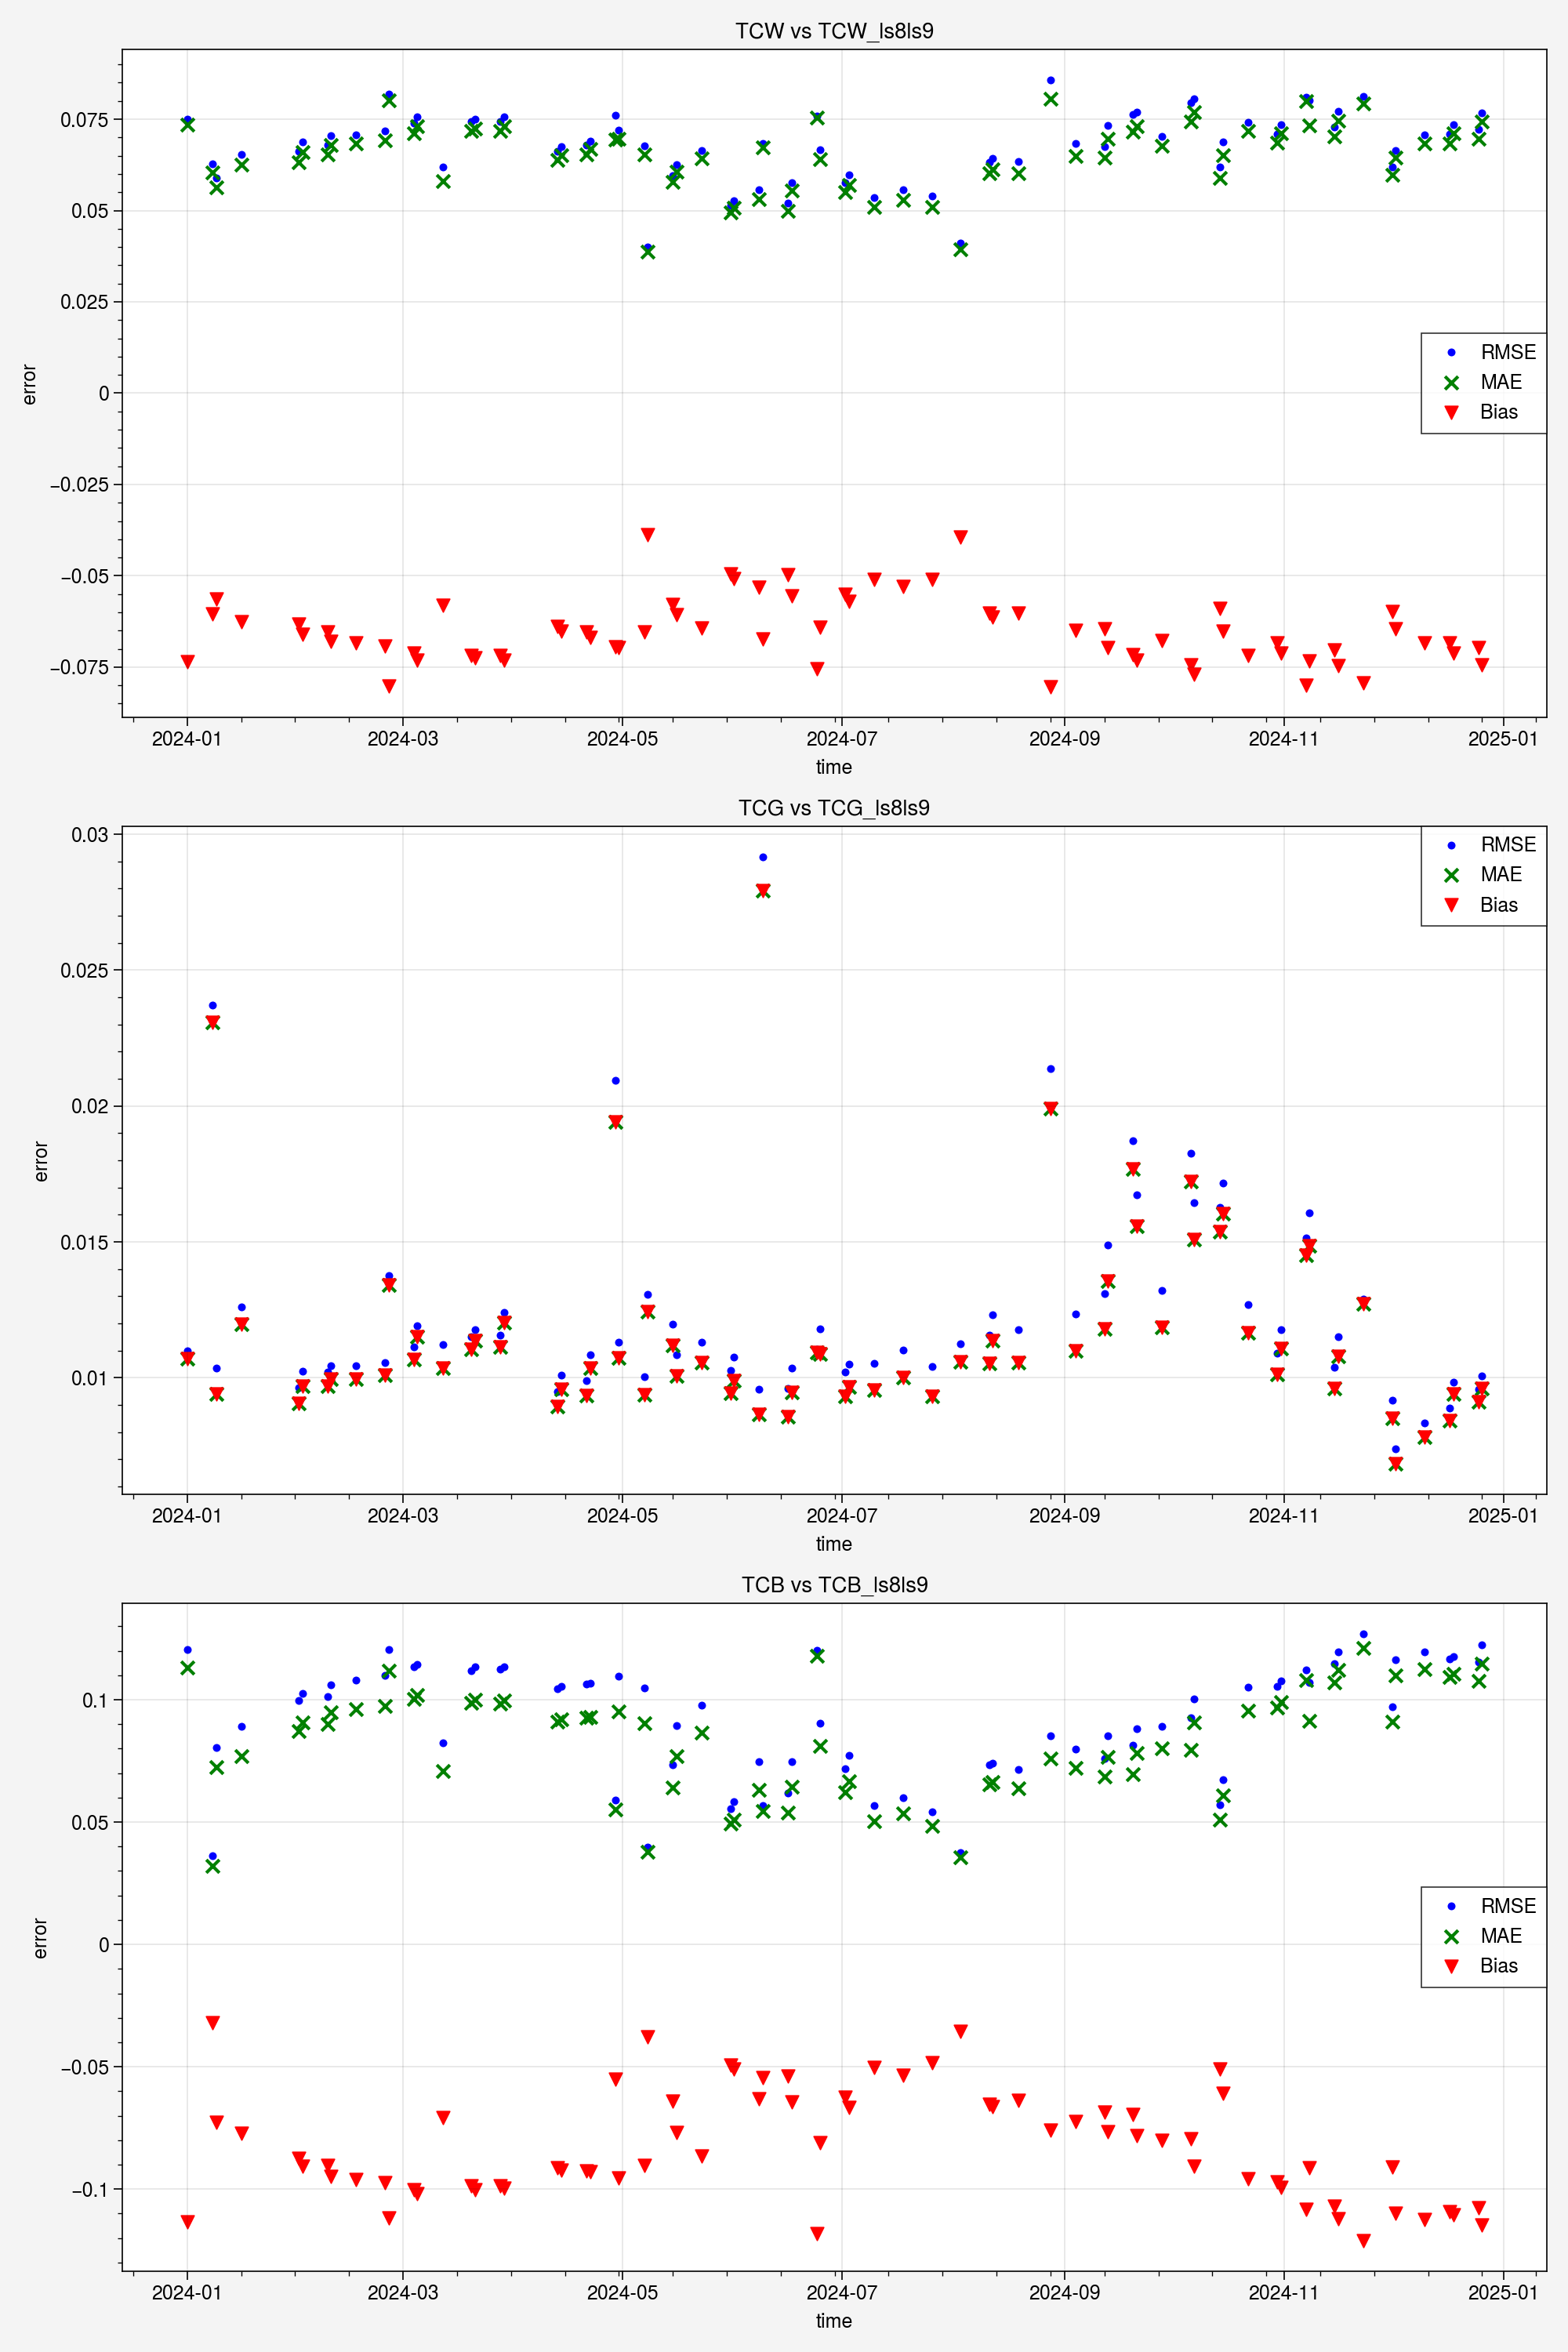

In [17]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(6,9))

for i, (var1, var2) in enumerate(variable_pairs):
    ax=axs[i]
    diff = ds_tc_sub[var1] - ds_tc_sub[var2]
    rmse = np.sqrt((diff ** 2).mean(dim=['x', 'y']))
    mae = np.abs(diff).mean(dim=['x', 'y'])
    bias = diff.mean(dim=['x', 'y'])
    #plot the metrics
    ax.scatter(ds_tc_sub['time'], rmse, label='RMSE', c='blue', marker='.')
    ax.scatter(ds_tc_sub['time'], mae, label='MAE', c='green', marker='x')
    ax.scatter(ds_tc_sub['time'], bias, label='Bias', c='red', marker='v')
    ax.set_title(f'{var1} vs {var2}')
    ax.set_xlabel('time')
    ax.set_ylabel('error')
    ax.legend()

plt.tight_layout()
plt.show()

In [18]:
ds_tc_sub['time'] = pd.to_datetime(ds_tc_sub['time'].values)
monthly_groups = ds_tc_sub.groupby('time.month')

# for month, group in monthly_groups:
#     print(f'month: {month}')
#     print(group)
#     print('\n')

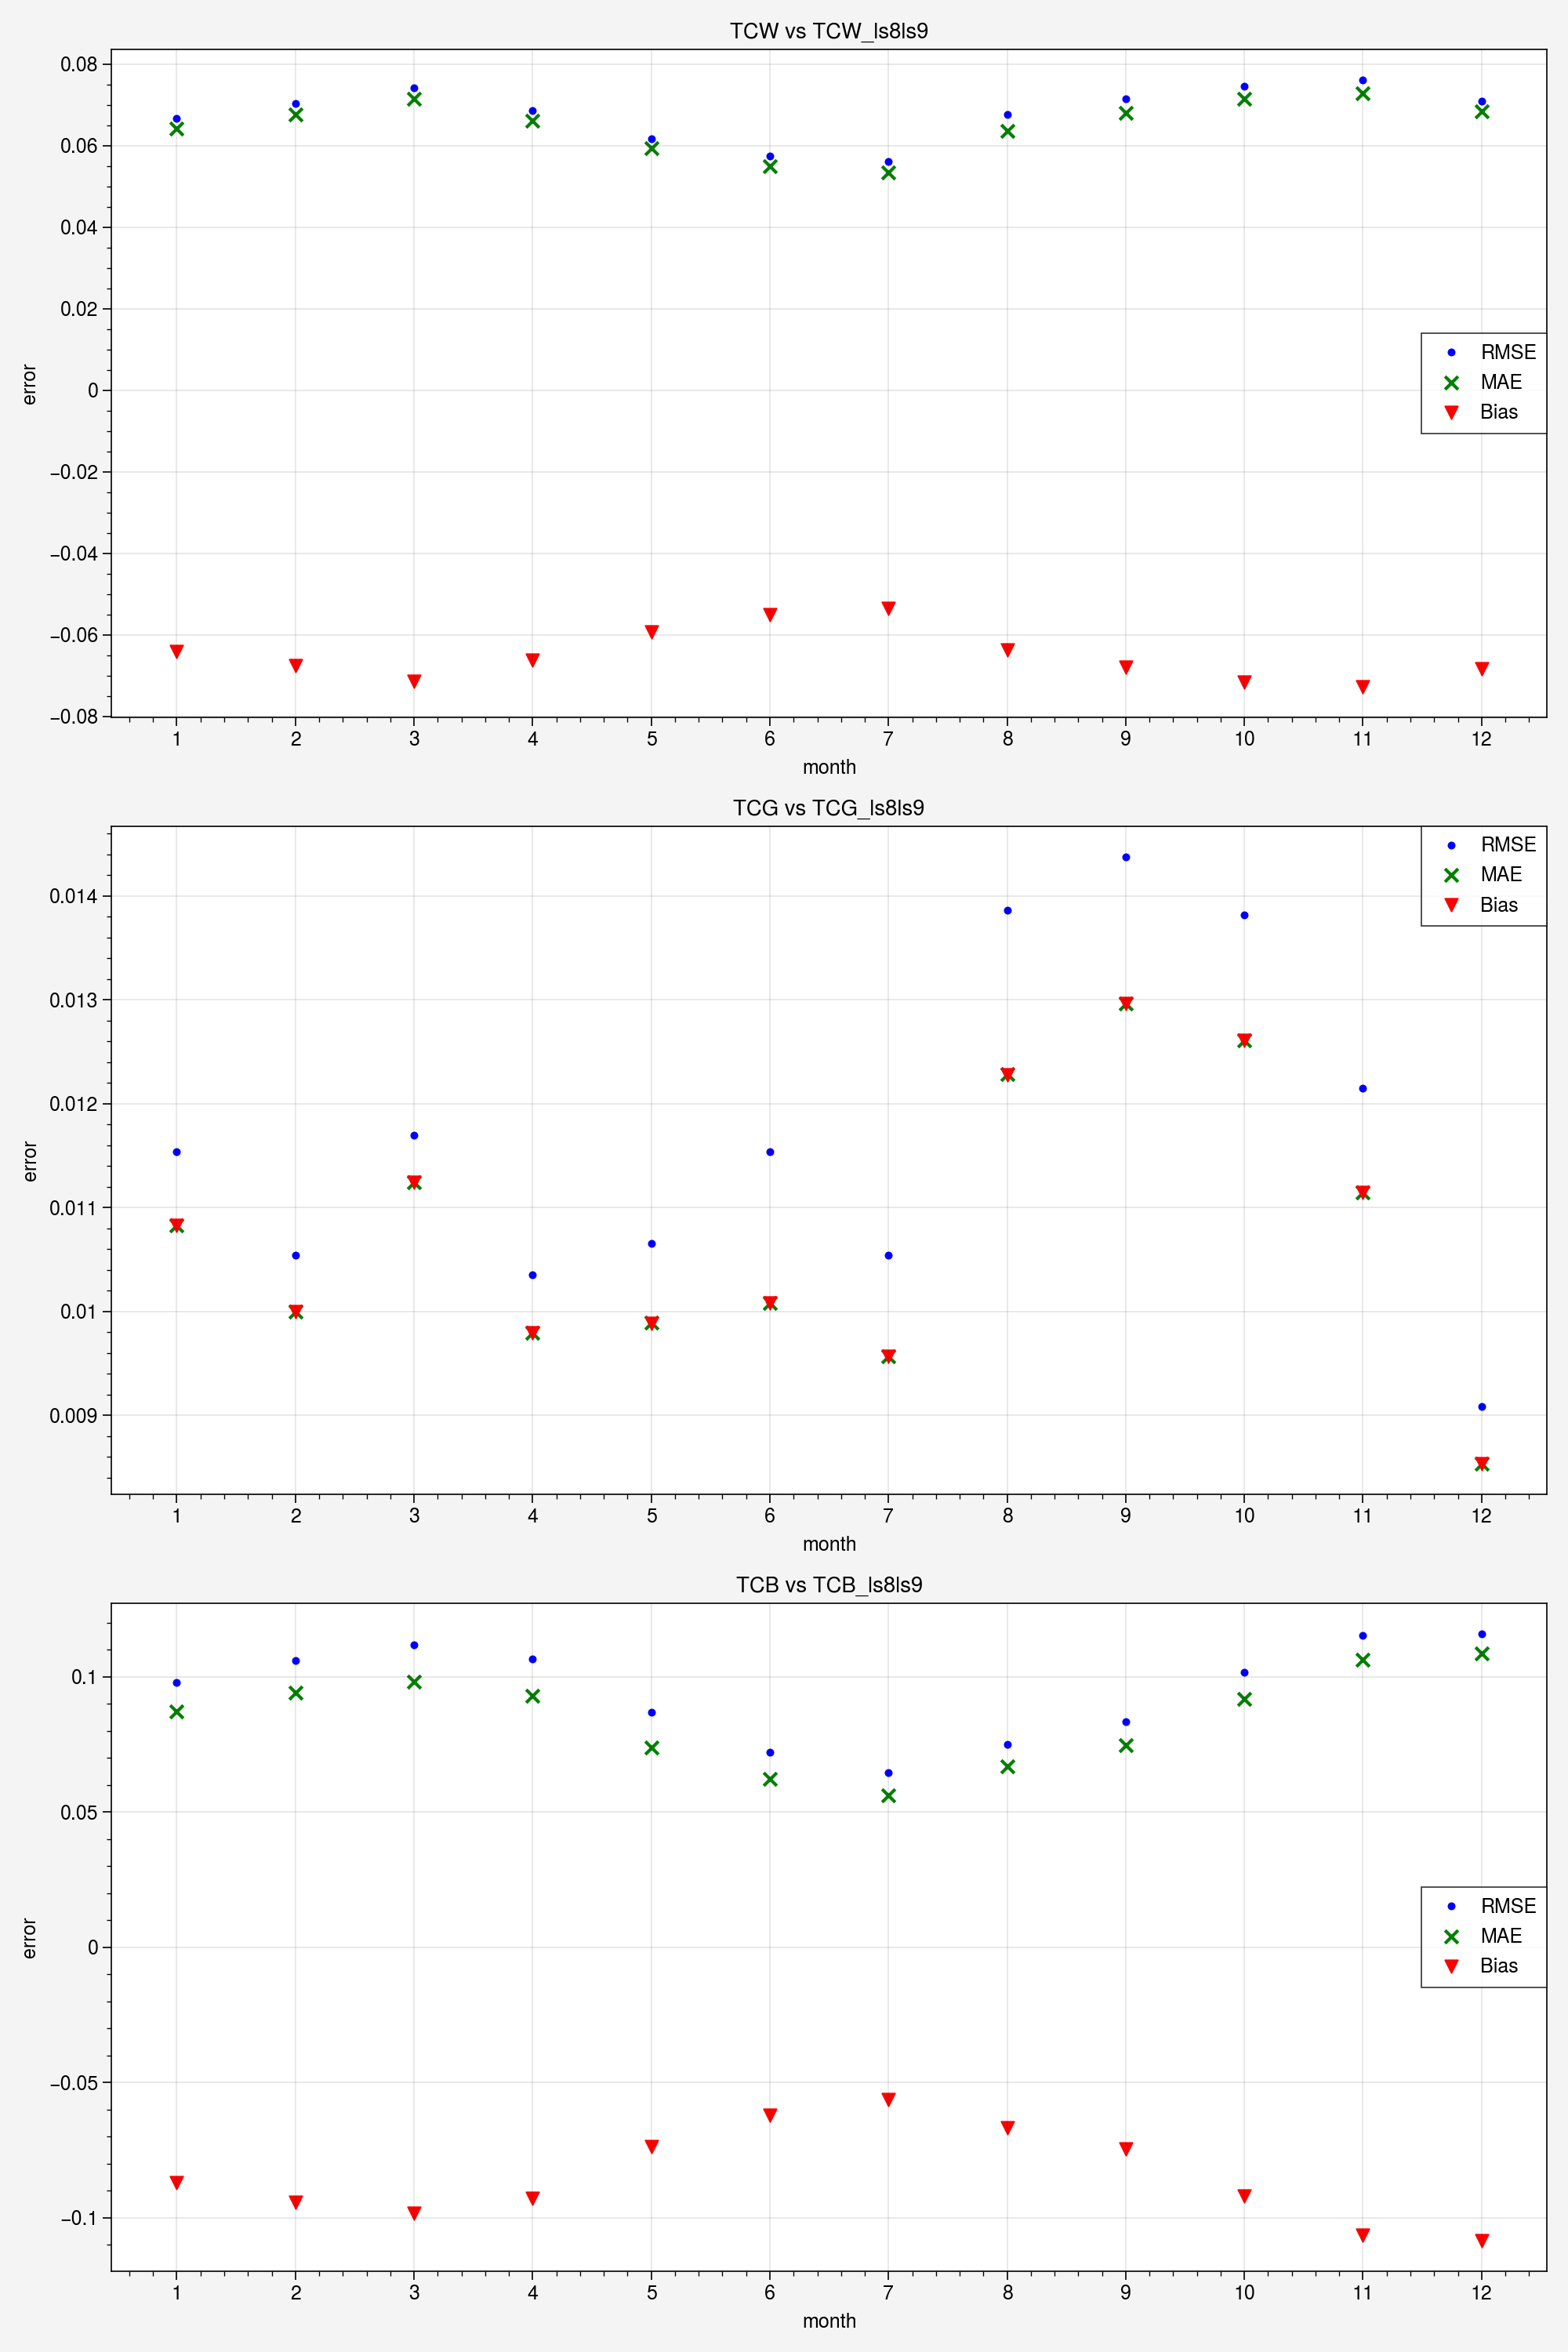

In [19]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10,15))


for i, (var1, var2) in enumerate(variable_pairs):
    ax=axs[i]
    
    months = []
    rmse_values = []
    mae_values = []
    bias_values = []

    for month, group in monthly_groups:
        months.append(month)
        
        diff = group[var1] - group[var2]
        rmse = np.sqrt((diff ** 2).mean(dim=['x', 'y', 'time'])).item()
        mae = np.abs(diff).mean(dim=['x', 'y', 'time']).item()
        bias = diff.mean(dim=['x', 'y', 'time']).item()
        
        rmse_values.append(rmse)
        mae_values.append(mae)
        bias_values.append(bias)

    ax.scatter(months, rmse_values, label='RMSE', c='blue', marker='.')
    ax.scatter(months, mae_values, label='MAE', c='green', marker='x')
    ax.scatter(months, bias_values, label='Bias', c='red', marker='v')
    ax.set_title(f'{var1} vs {var2}')
    ax.set_xlabel('month')
    ax.set_ylabel('error')
    ax.set_xticks(range(1,13))
    ax.legend()

plt.tight_layout()
plt.show()
        

In [20]:
#diff_month = difference.groupby('time.month').median('time')

#diff_month.plot(col='month', col_wrap=3, robust=True)

In [30]:
wofs_measurements= ['frequency']
wofs_query = query

wofs_query.update({
    'measurements':wofs_measurements
})

In [31]:
ds_wofs = dc.load(
    product='ga_ls_wo_fq_cyear_3',
    **query
)

In [37]:
wofs_mask = 0.4

ds_wofs['wet_pixels'] = ds_wofs['frequency'].where(ds_wofs['frequency'] > wofs_mask)
ds_wofs

<xarray.Dataset> Size: 1MB
Dimensions:      (time: 1, y: 398, x: 336)
Coordinates:
  * time         (time) datetime64[ns] 8B 2024-07-01T23:59:59.999999
  * y            (y) float64 3kB -3.925e+06 -3.925e+06 ... -3.937e+06 -3.937e+06
  * x            (x) float64 3kB 1.08e+06 1.08e+06 ... 1.09e+06 1.09e+06
    spatial_ref  int32 4B 3577
Data variables:
    frequency    (time, y, x) float32 535kB 0.0 0.0 0.0 ... 0.0 0.3478 0.6327
    wet_pixels   (time, y, x) float32 535kB nan nan nan nan ... nan nan 0.6327
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [34]:
# broadcast the single timestep wofs data to all timesteps in the tc array.
ds_tc_sub['wofs_frequency'] =ds_wofs['frequency'].isel(time=0).expand_dims(time=ds_tc_sub.time)
ds_tc_sub['wofs_wet_pixels'] =ds_wofs['wet_pixels'].isel(time=0).expand_dims(time=ds_tc_sub.time)
ds_tc_sub

<xarray.Dataset> Size: 487MB
Dimensions:         (time: 91, y: 398, x: 336)
Coordinates:
  * time            (time) datetime64[ns] 728B 2024-01-01T00:09:22.123303 ......
  * y               (y) float64 3kB -3.925e+06 -3.925e+06 ... -3.937e+06
  * x               (x) float64 3kB 1.08e+06 1.08e+06 ... 1.09e+06 1.09e+06
    spatial_ref     int32 4B 3577
Data variables:
    TCW             (time, y, x) float32 49MB -0.2619 -0.2562 ... 0.003667
    TCB             (time, y, x) float32 49MB 0.3231 0.3168 ... 0.09733 0.08216
    TCG             (time, y, x) float32 49MB 0.05477 0.0639 ... 0.002717
    TCW_ls8ls9      (time, y, x) float32 49MB -0.1752 -0.1713 ... 0.01787
    TCB_ls8ls9      (time, y, x) float32 49MB 0.4685 0.4578 ... 0.1007 0.08578
    TCG_ls8ls9      (time, y, x) float32 49MB 0.04334 0.05293 ... -0.002771
    TCW_diff        (time, y, x) float32 49MB -0.0867 -0.0849 ... -0.01421
    TCG_diff        (time, y, x) float32 49MB 0.01143 0.01097 ... 0.005488
    TCB_diff        (time, y, x) float32 49MB -0.1453 -0.141 ... -0.003615
    wofs_frequency  (time, y, x) float32 49MB 0.0 0.0 0.0 ... 0.0 0.3478 0.6327
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [24]:
# make bitmask for wofs with >50% frequency to class wet pixels
# use SMAD to find ag areas and classify as ag pixels
# use SMAD to classify native veg pixels